# Figures 4 and 5 — Basis-attractor decomposition and PLSR reconstruction

This notebook reproduces the **Poincaré-FTLE analysis pipeline** used in the manuscript to generate **Fig. 4** and **Fig. 5**, where the internal mechanics of the geometry-guided framework are made explicit.

Whereas the ML-FTLE section establishes that predictive forecast divergence can recover a finite-time Lyapunov proxy from scalar data, the present notebook addresses the second part of the manuscript's central claim: that the **macroscopic geometry of the reconstructed attractor** also contains sufficient information to recover the same instability transition on the Lyapunov scale.

The workflow follows the three-phase structure described in the manuscript:

| Phase | Role in the manuscript |
| ------ | ---------------------- |
| Phase 1 | Convert each sliding temporal window into a binary Poincaré occupancy grid |
| Phase 2 | Select a compact basis set of maximally dissimilar representative attractors using the greedy max-min rule |
| Phase 3 | Regress the resulting closeness coordinates onto the ML-FTLE target using one-component PLSR |

For the manuscript figures, this notebook visualises how the representative basis attractors are chosen, how the closeness matrix evolves across time, and how the first supervised latent variable reconstructs the geometric transition that underlies the calibrated proxy $\hat{\lambda}_{\mathrm{geo}}^{(m)}$.

---

## Execution order

| Cell block | Purpose | Run order |
| ---------- | ------- | --------- |
| `c01`–`c03` | Imports, parameter discovery, core Poincaré-FTLE helpers | once |
| `c04_compute` | Full geometry extraction, representative selection, closeness matrix, and PLSR fit | once per session |
| `c05_plot_fig1_basis_overview` | Publication composite for Fig. 4 | re-run freely |
| `c06_plot_fig2_plsr_dynamics` | Publication composite for Fig. 5 | re-run freely |
| `c07_summary` | Tabulated summary of selected representatives and PLSR correlation | optional |

The notebook is designed so that the expensive geometric computation is done once, after which the figure cells can be restyled and re-exported independently during manuscript preparation.



### `c01_imports` — Scientific plotting and analysis imports

Loads the numerical, plotting, and statistical utilities required for the basis-attractor analysis.

In addition to `numpy`, `pandas`, and `matplotlib`, this notebook uses `gridspec` for multi-panel composite figures and `spearmanr` for summarising monotonic agreement between the geometric reconstructions and the ML-FTLE reference.



In [8]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.stats import spearmanr
print('Imports OK')


Imports OK


### `c02_params` — Auto-discover all parameter sets

Discovers every dataset configuration defined in `parameters/data_N.py` and extracts the shared hyperparameters used by the Poincaré-FTLE pipeline.

These parameters determine the sliding-window length, stride, Poincaré lag, grid resolution, number of representatives, plotting defaults, and the set of dissimilarity metrics $m \in \{\mathrm{JSD}, \mathrm{SSIM}, \mathrm{HDF}, \mathrm{IOU}\}$ evaluated in the manuscript.

The cell also checks whether each dataset already contains the prerequisite `ml_ftle.csv`, since Phase 3 calibrates the geometric coordinates against the previously computed ML-FTLE target rather than against the analytical QR-FTLE.



In [9]:
from parameters import discover_all_params

EPS        = 1e-12
PARAM_SETS = discover_all_params()
DATASETS   = [P.OUT_DIR for P in PARAM_SETS.values()]

print(f'Datasets ({len(DATASETS)}):')
for _did, _P in PARAM_SETS.items():
    _csv_dir  = _P.OUT_DIR / 'csv_mkg'
    _ftle_csv = _P.OUT_DIR / 'ml_ftle.csv'
    _n        = len(list(_csv_dir.glob('*.csv'))) if _csv_dir.exists() else 0
    print(f'  {_did:20s}  csv_mkg:{_n}  '
          f'ml_ftle:{"✓" if _ftle_csv.exists() else "✗ MISSING"}')

# Snapshot shared scalars from the first parameter set so they are available
# to every plot cell without re-importing PARAM_SETS.
if PARAM_SETS:
    _P0            = next(iter(PARAM_SETS.values()))
    WINDOW         = _P0.T_WINDOW_STEPS
    STEP           = _P0.T_STEP
    BINS           = _P0.BINS
    METHODS        = _P0.POINCARE_METHODS
    LLE_THRESH     = _P0.LLE_THRESH
    NN             = _P0.NN_POINCARE
    METHOD_COLORS  = _P0.METHOD_COLORS
    GRID_ALPHA     = _P0.GRID_ALPHA
    DPI_PLOT       = _P0.DPI_PLOT
    DPI_COMPOSITE  = _P0.DPI_COMPOSITE
    LINE_WIDTH     = _P0.LINE_WIDTH
    COLORS_REP     = _P0.COLORS_REP
    print(f'\nParams: WINDOW={WINDOW}  STEP={STEP}  BINS={BINS}  NN={NN}')
    print(f'Methods: {METHODS}')


Discovered 1 parameter file(s) in d:\NLD_PROJECT\ML_FTLE\publication code\parameters:
  ✓  data_1.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1
Datasets (1):
  data_1                csv_mkg:1  ml_ftle:✓

Params: WINDOW=500  STEP=30  BINS=20  NN=6
Methods: ['JSD', 'SSIM', 'HDF', 'IOU']


### `c03_core` — Import the Poincaré-FTLE core functions

Imports the helper functions from `core/poincare_ftle.py` that implement the manuscript's geometry-guided pipeline.

These functions cover the full workflow: construction of lagged Poincaré occupancy grids, greedy representative selection, metric-specific geometric dissimilarity, loading of the ML-FTLE reference series, and one-component PLSR calibration from geometric closeness coordinates to the Lyapunov-scale proxy.



In [10]:
from core.poincare_ftle import (
    run_phase1_2,
    run_phase3_plsr,
    load_ftle,
    poincare_grid_and_hist,
    select_representatives,
    read_table_any_sep,
    raw_metric_value,
    difference_score,
)
print('core.poincare_ftle imported OK')


core.poincare_ftle imported OK


### `c04_compute` — Full geometric decomposition and PLSR fit *(run once per session)*

This is the main computational cell for the manuscript's **Poincaré-FTLE** section.

For each dataset, the code performs the following steps:
1. loads the scalar observable from the precomputed signal CSV,
2. runs **Phase 1+2** through `run_phase1_2()` to generate the Poincaré occupancy grids and choose a compact representative basis set,
3. loads the precomputed ML-FTLE reference trajectory from `ml_ftle.csv`,
4. runs **Phase 3** through `run_phase3_plsr()` to obtain the one-component PLSR reconstruction,
5. rebuilds all windowed Poincaré grids explicitly for visualisation, and
6. forms the normalised closeness matrix
   
   $   c_{i,r} = 1 - \frac{D^{(m)}(i,r)}{D_{\max}^{(m)}},$
   
   which is the central geometric state representation used throughout Figs. 4 and 5.

In the language of the manuscript, this cell converts a non-stationary scalar trajectory into a **time-resolved geometric coordinate system** whose axes are the selected basis attractors. The resulting payload stored in `all_compute[dataset][method]` contains everything required to visualise representative windows, closeness trajectories, latent dynamics, and the calibrated geometric FTLE proxy.



In [11]:

all_compute = {}   # data_id → method → payload dict

for dset in DATASETS:
    print(f'\n{"="*65}\n  Dataset: {dset.name}\n{"="*65}')
    _P = PARAM_SETS.get(dset.name, next(iter(PARAM_SETS.values())))

    # ── per-dataset parameter snapshot ───────────────────────────────────
    WINDOW        = _P.T_WINDOW_STEPS
    STEP          = _P.T_STEP
    BINS          = _P.BINS
    METHODS       = _P.POINCARE_METHODS
    LLE_THRESH    = _P.LLE_THRESH
    NN            = _P.NN_POINCARE
    METHOD_COLORS = _P.METHOD_COLORS
    GRID_ALPHA    = _P.GRID_ALPHA
    DPI_PLOT      = _P.DPI_PLOT
    DPI_COMPOSITE = _P.DPI_COMPOSITE
    LINE_WIDTH    = _P.LINE_WIDTH
    COLORS_REP    = _P.COLORS_REP

    # ── load scalar signal ────────────────────────────────────────────────
    csv_dir   = dset / 'csv_mkg'
    csv_files = sorted(csv_dir.glob('*.csv')) if csv_dir.exists() else []
    if not csv_files:
        print('  No signal CSVs — skip'); continue
    df_raw = read_table_any_sep(csv_files[0])
    tsig   = df_raw.iloc[:, 0].values.astype(float)
    signal = df_raw.iloc[:, 1].values.astype(float)

    # ── Phase 1+2: Poincaré grids + greedy max-min basis selection ───────
    frames, recalc = run_phase1_2(dset, _P)
    if frames is None:
        print('  Phase 1+2 failed — skip'); continue

    # ── Phase 3: PLSR onto ML-FTLE ────────────────────────────────────────
    ftle_csv                    = dset / 'ml_ftle.csv'
    t_ftle, lam_ml              = None, None
    pred_dict, pc1_dict         = {}, {}
    if ftle_csv.exists():
        t_ftle, lam_ml = load_ftle(ftle_csv)
        fit            = run_phase3_plsr(dset, recalc, t_ftle, lam_ml, n_components=1)
        pred_dict      = {m: (r['pred'], r['rho']) for m, r in fit.items()}
        pc1_dict       = {m: (r['pc1'],  r['t_m']) for m, r in fit.items()}
        print(f'  PLSR done: {list(pred_dict.keys())}')
    else:
        print('  ml_ftle.csv missing — plotting without PLSR overlay and PC1')

    # ── build all Poincaré occupancy grids for this dataset ──────────────
    idx_starts = np.arange(0, signal.size - WINDOW + 1, STEP, dtype=int)
    centers    = tsig[idx_starts + WINDOW // 2]
    print(f'  Building {len(idx_starts)} grids...')
    grids = [
        poincare_grid_and_hist(
            signal[s: s + WINDOW],
            bins=BINS, lag=_P.POINCARE_LAG,
            connect_lines=_P.CONNECT_LINES,
            line_thick=_P.LINE_THICK,
        )[0]
        for s in idx_starts
    ]
    print(f'  Grids built: {len(grids)}')

    all_compute[dset.name] = {}

    for method in METHODS:
        if method not in recalc:
            print(f'  [{method}] not in recalc — skip'); continue

        sel    = recalc[method]['sel']
        base   = max(recalc[method]['base'], EPS)
        cache  = {}

        def get_diff(i, j, _m=method, _cache=cache):
            """Cached pairwise difference score between window i and j."""
            k = (min(i, j), max(i, j))
            if k not in _cache:
                raw        = raw_metric_value(_m, grids[k[0]], grids[k[1]], bins=BINS)
                _cache[k]  = difference_score(_m, raw)
            return _cache[k]

        # Normalised closeness: c_{i,r} = 1 − diff(i, rep_r) / base
        n      = len(grids)
        cl_mat = np.column_stack([
            np.array([1.0 - get_diff(i, rep) / base for i in range(n)])
            for rep in sel
        ])

        pred, plsr_rho, pc1, t_pc1 = None, None, None, None
        if method in pred_dict:
            pred, plsr_rho = pred_dict[method]
        if method in pc1_dict:
            pc1, t_pc1 = pc1_dict[method]

        print(f'  [{method}]  sel={sel}')

        all_compute[dset.name][method] = dict(
            P=_P, dset=dset, method=method,
            signal=signal, tsig=tsig,
            centers=centers, grids=grids, sel=sel,
            cl_mat=cl_mat,
            t_ftle=t_ftle, lam_ml=lam_ml,
            pred=pred, plsr_rho=plsr_rho,
            pc1=pc1, t_pc1=t_pc1,
        )

print('\n✓ Compute complete for all datasets.')



  Dataset: data_1
  [JSD] ode_trajectory: 6 reps, base=0.8087
  [SSIM] ode_trajectory: 6 reps, base=0.4854
  [HDF] ode_trajectory: 6 reps, base=8.062
  [IOU] ode_trajectory: 6 reps, base=0.816
  PLSR done: ['JSD', 'SSIM', 'HDF', 'IOU']
  Building 184 grids...
  Grids built: 184
  [JSD]  sel=[15, 52, 71, 92, 131, 174]
  [SSIM]  sel=[15, 52, 71, 92, 131, 174]
  [HDF]  sel=[0, 53, 71, 92, 128, 167]
  [IOU]  sel=[15, 52, 71, 92, 131, 174]

✓ Compute complete for all datasets.


## Figure 4 — Basis-attractor overview

This figure visualises the internal geometric decomposition of the trajectory for a chosen dissimilarity metric, matching the manuscript's presentation of **Fig. 4**.

The three rows show: **(a)** the raw scalar observable with coloured temporal anchors marking the representative windows selected by the greedy max-min algorithm, **(b)** the corresponding binary Poincaré occupancy grids that form the structural basis set $\mathcal{S}$, and **(c)** the time evolution of the normalised closeness scores $c_{i,r}$ that quantify how strongly each window resembles each representative attractor.

In manuscript terms, this figure demonstrates that the regime transition is not inferred from local forecast error alone; it is also encoded directly in the large-scale morphology of the reconstructed attractor.



### `c05_plot_fig1_basis_overview` — Publication plot for Fig. 4

Generates the three-row composite figure that exposes the basis-attractor mechanics of the Poincaré-FTLE framework.

#### Row 1 — Scalar signal with representative anchors
The top panel shows the raw scalar observable and overlays coloured temporal bands at the selected representative windows. These anchors correspond to the maximally dissimilar attractor states chosen under the metric-specific greedy max-min criterion with temporal separation constraints.

#### Row 2 — Representative Poincaré occupancy grids
The middle row displays the binary lagged Poincaré grids for the selected representatives. In the manuscript, these grids constitute the basis set $\mathcal{S}$ and provide a compact dictionary of the dominant geometric states encountered along the non-stationary trajectory.

#### Row 3 — Closeness matrix trajectories
The bottom panel plots the normalised closeness scores $c_{i,r}$ for every representative across time. This panel is the clearest visualisation of the geometric transition itself: dominance shifts from one subset of representatives to another as the attractor collapses, deforms, or settles into a different dynamical regime.

Together, these three rows reproduce the logic of manuscript Fig. 4: the framework first isolates a small number of geometrically distinct basis attractors and then expresses every sliding window as a time-dependent proximity pattern relative to that basis.



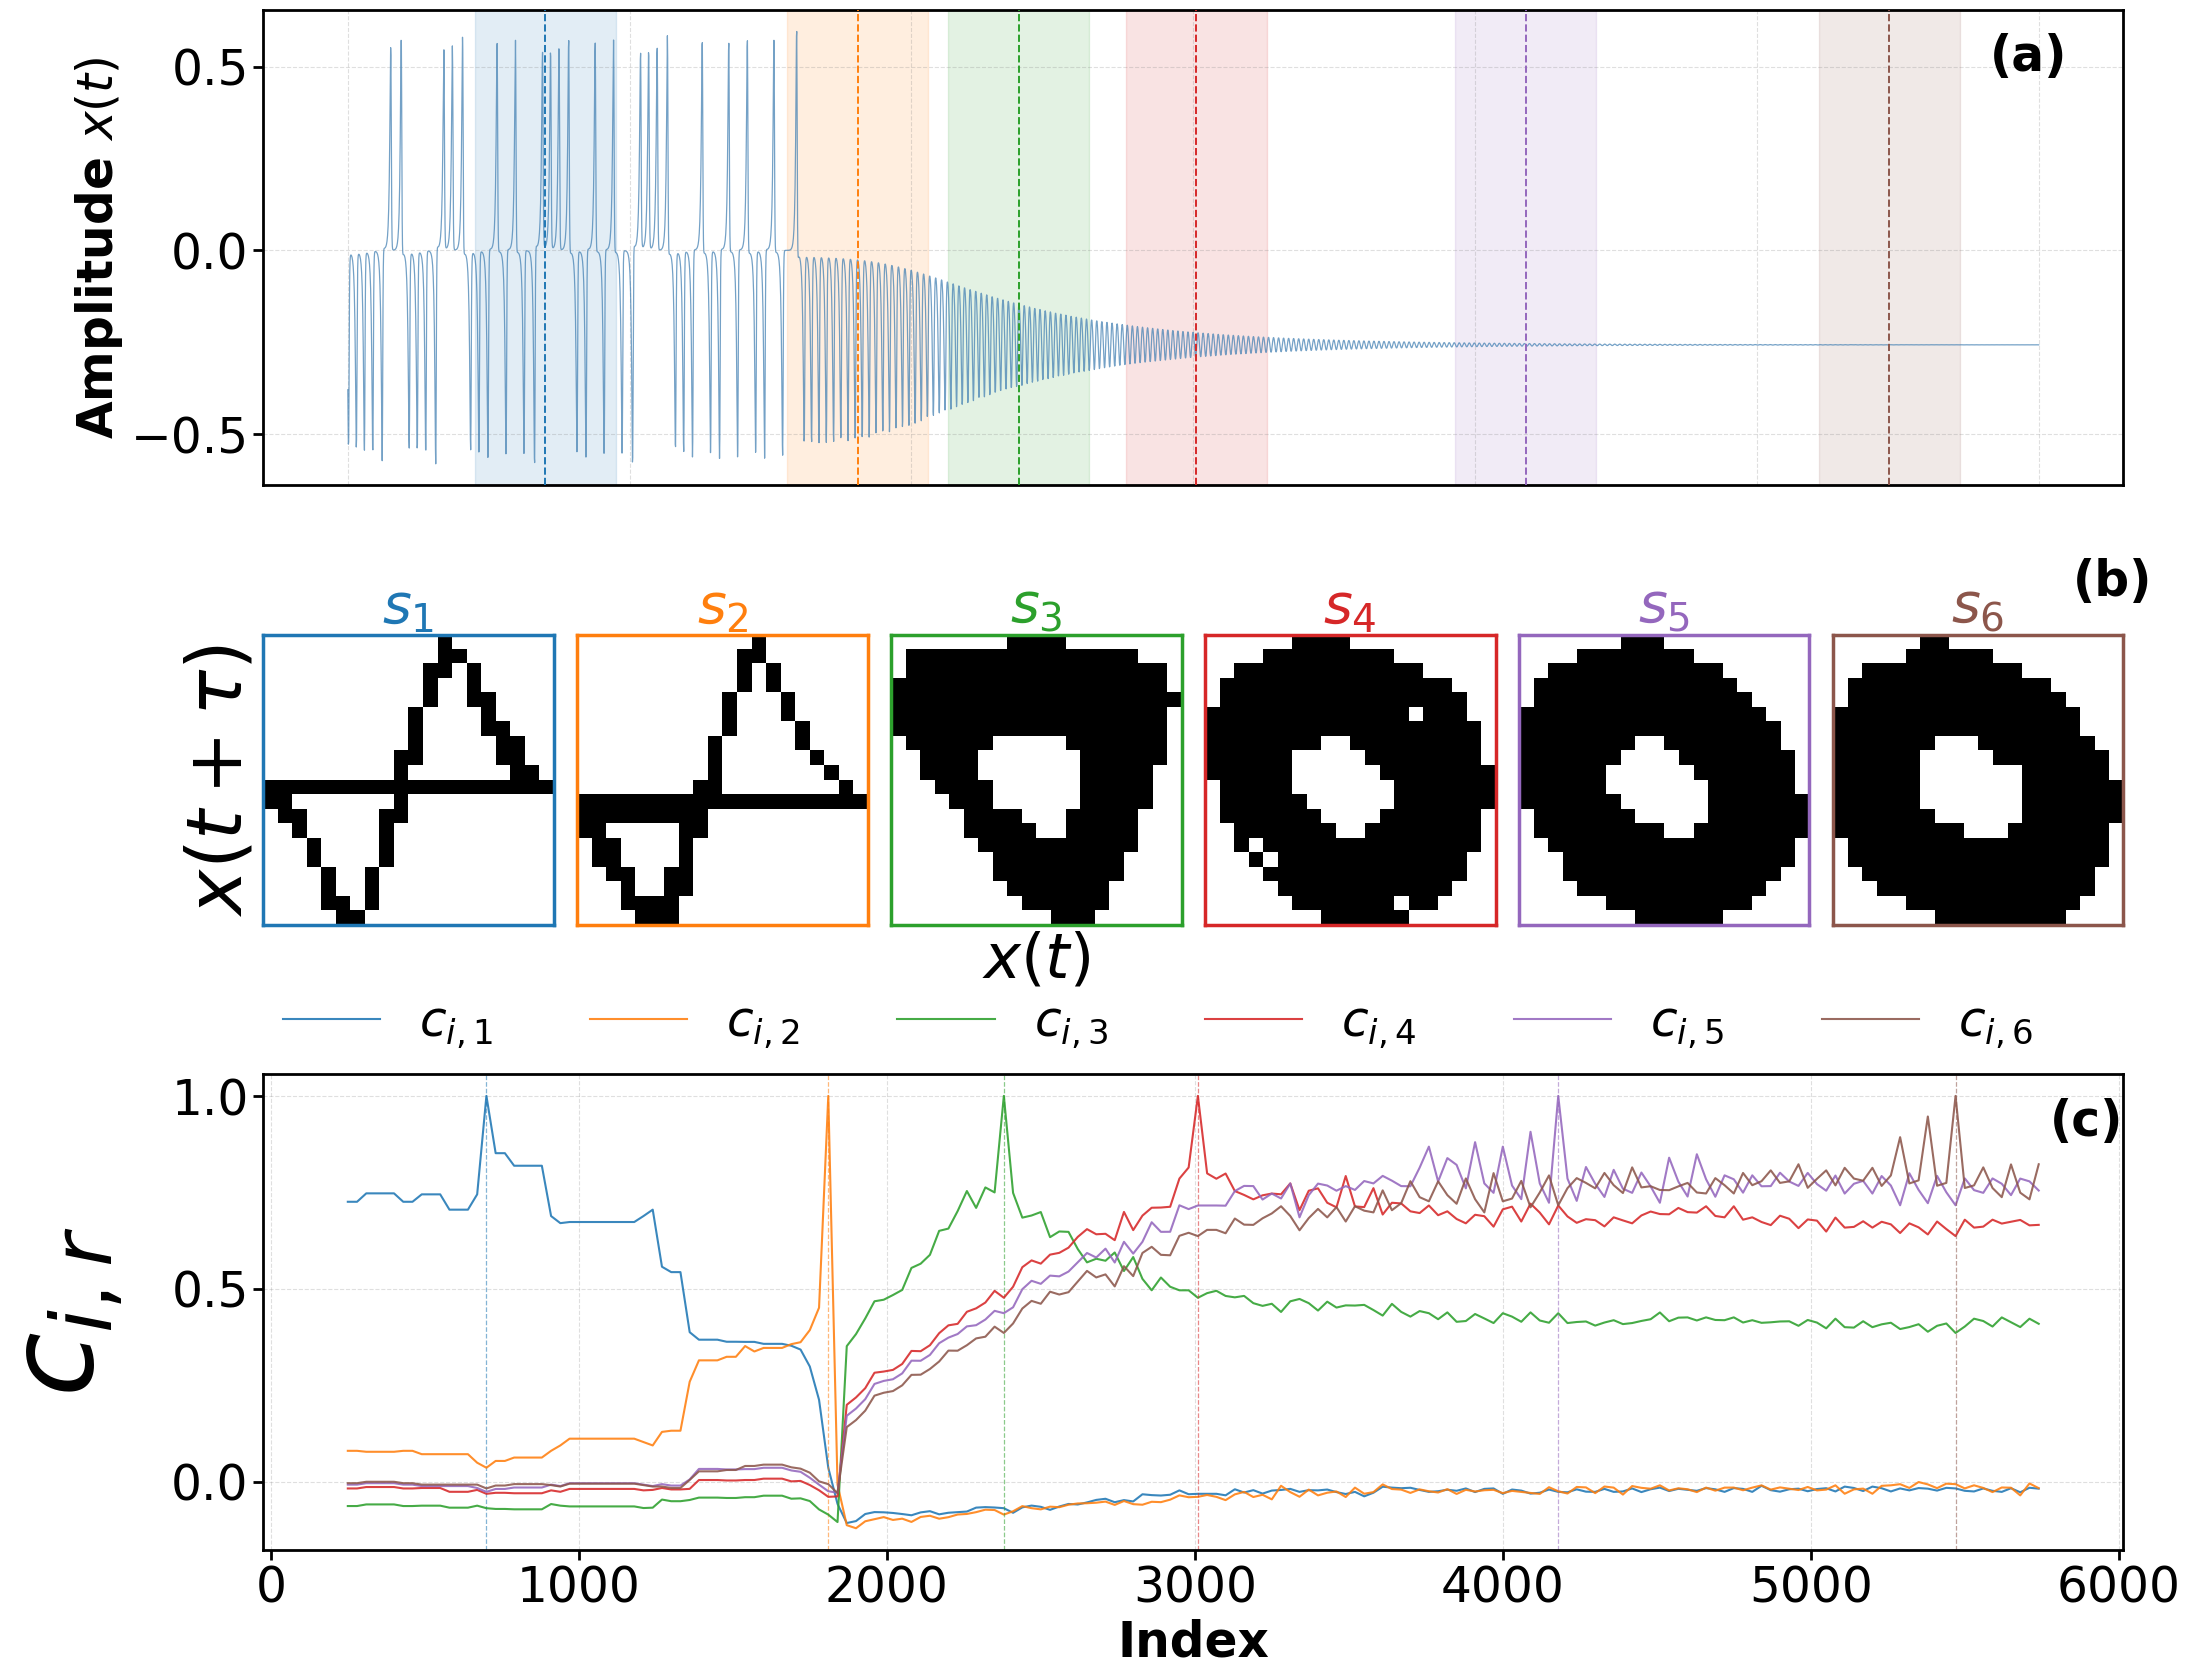

  [Fig1] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_4_JSD.pdf


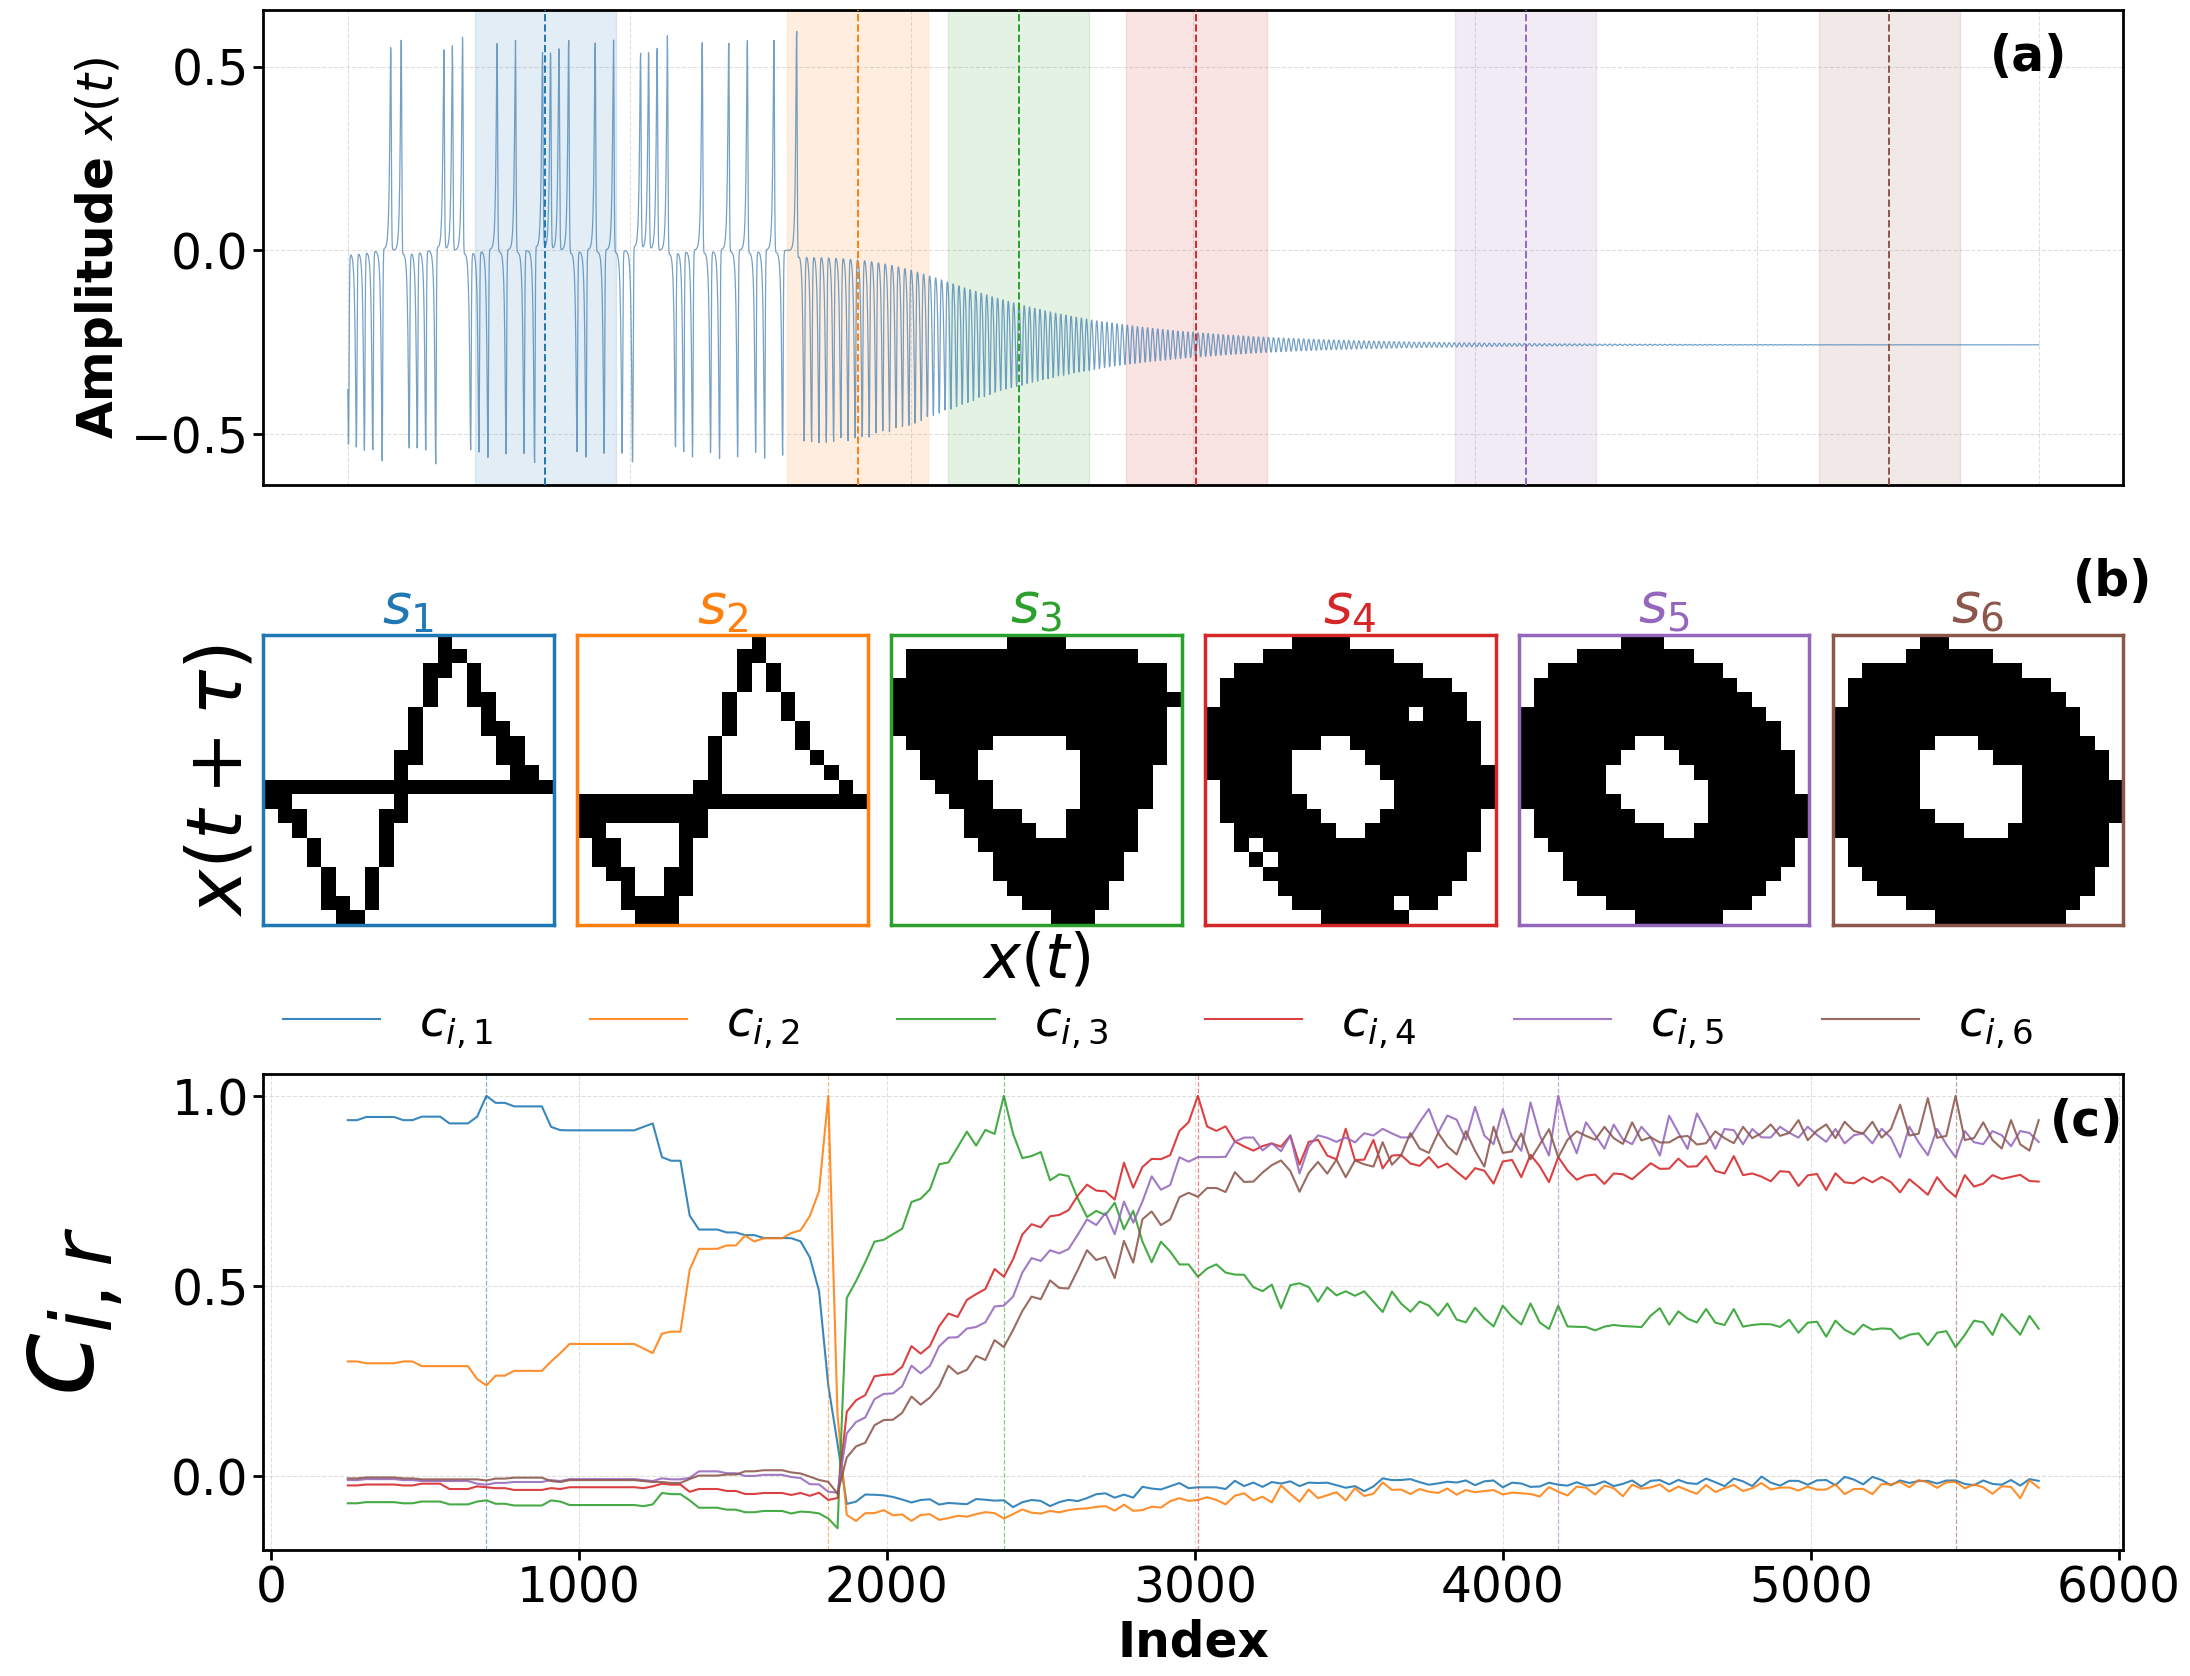

  [Fig1] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_4_SSIM.pdf


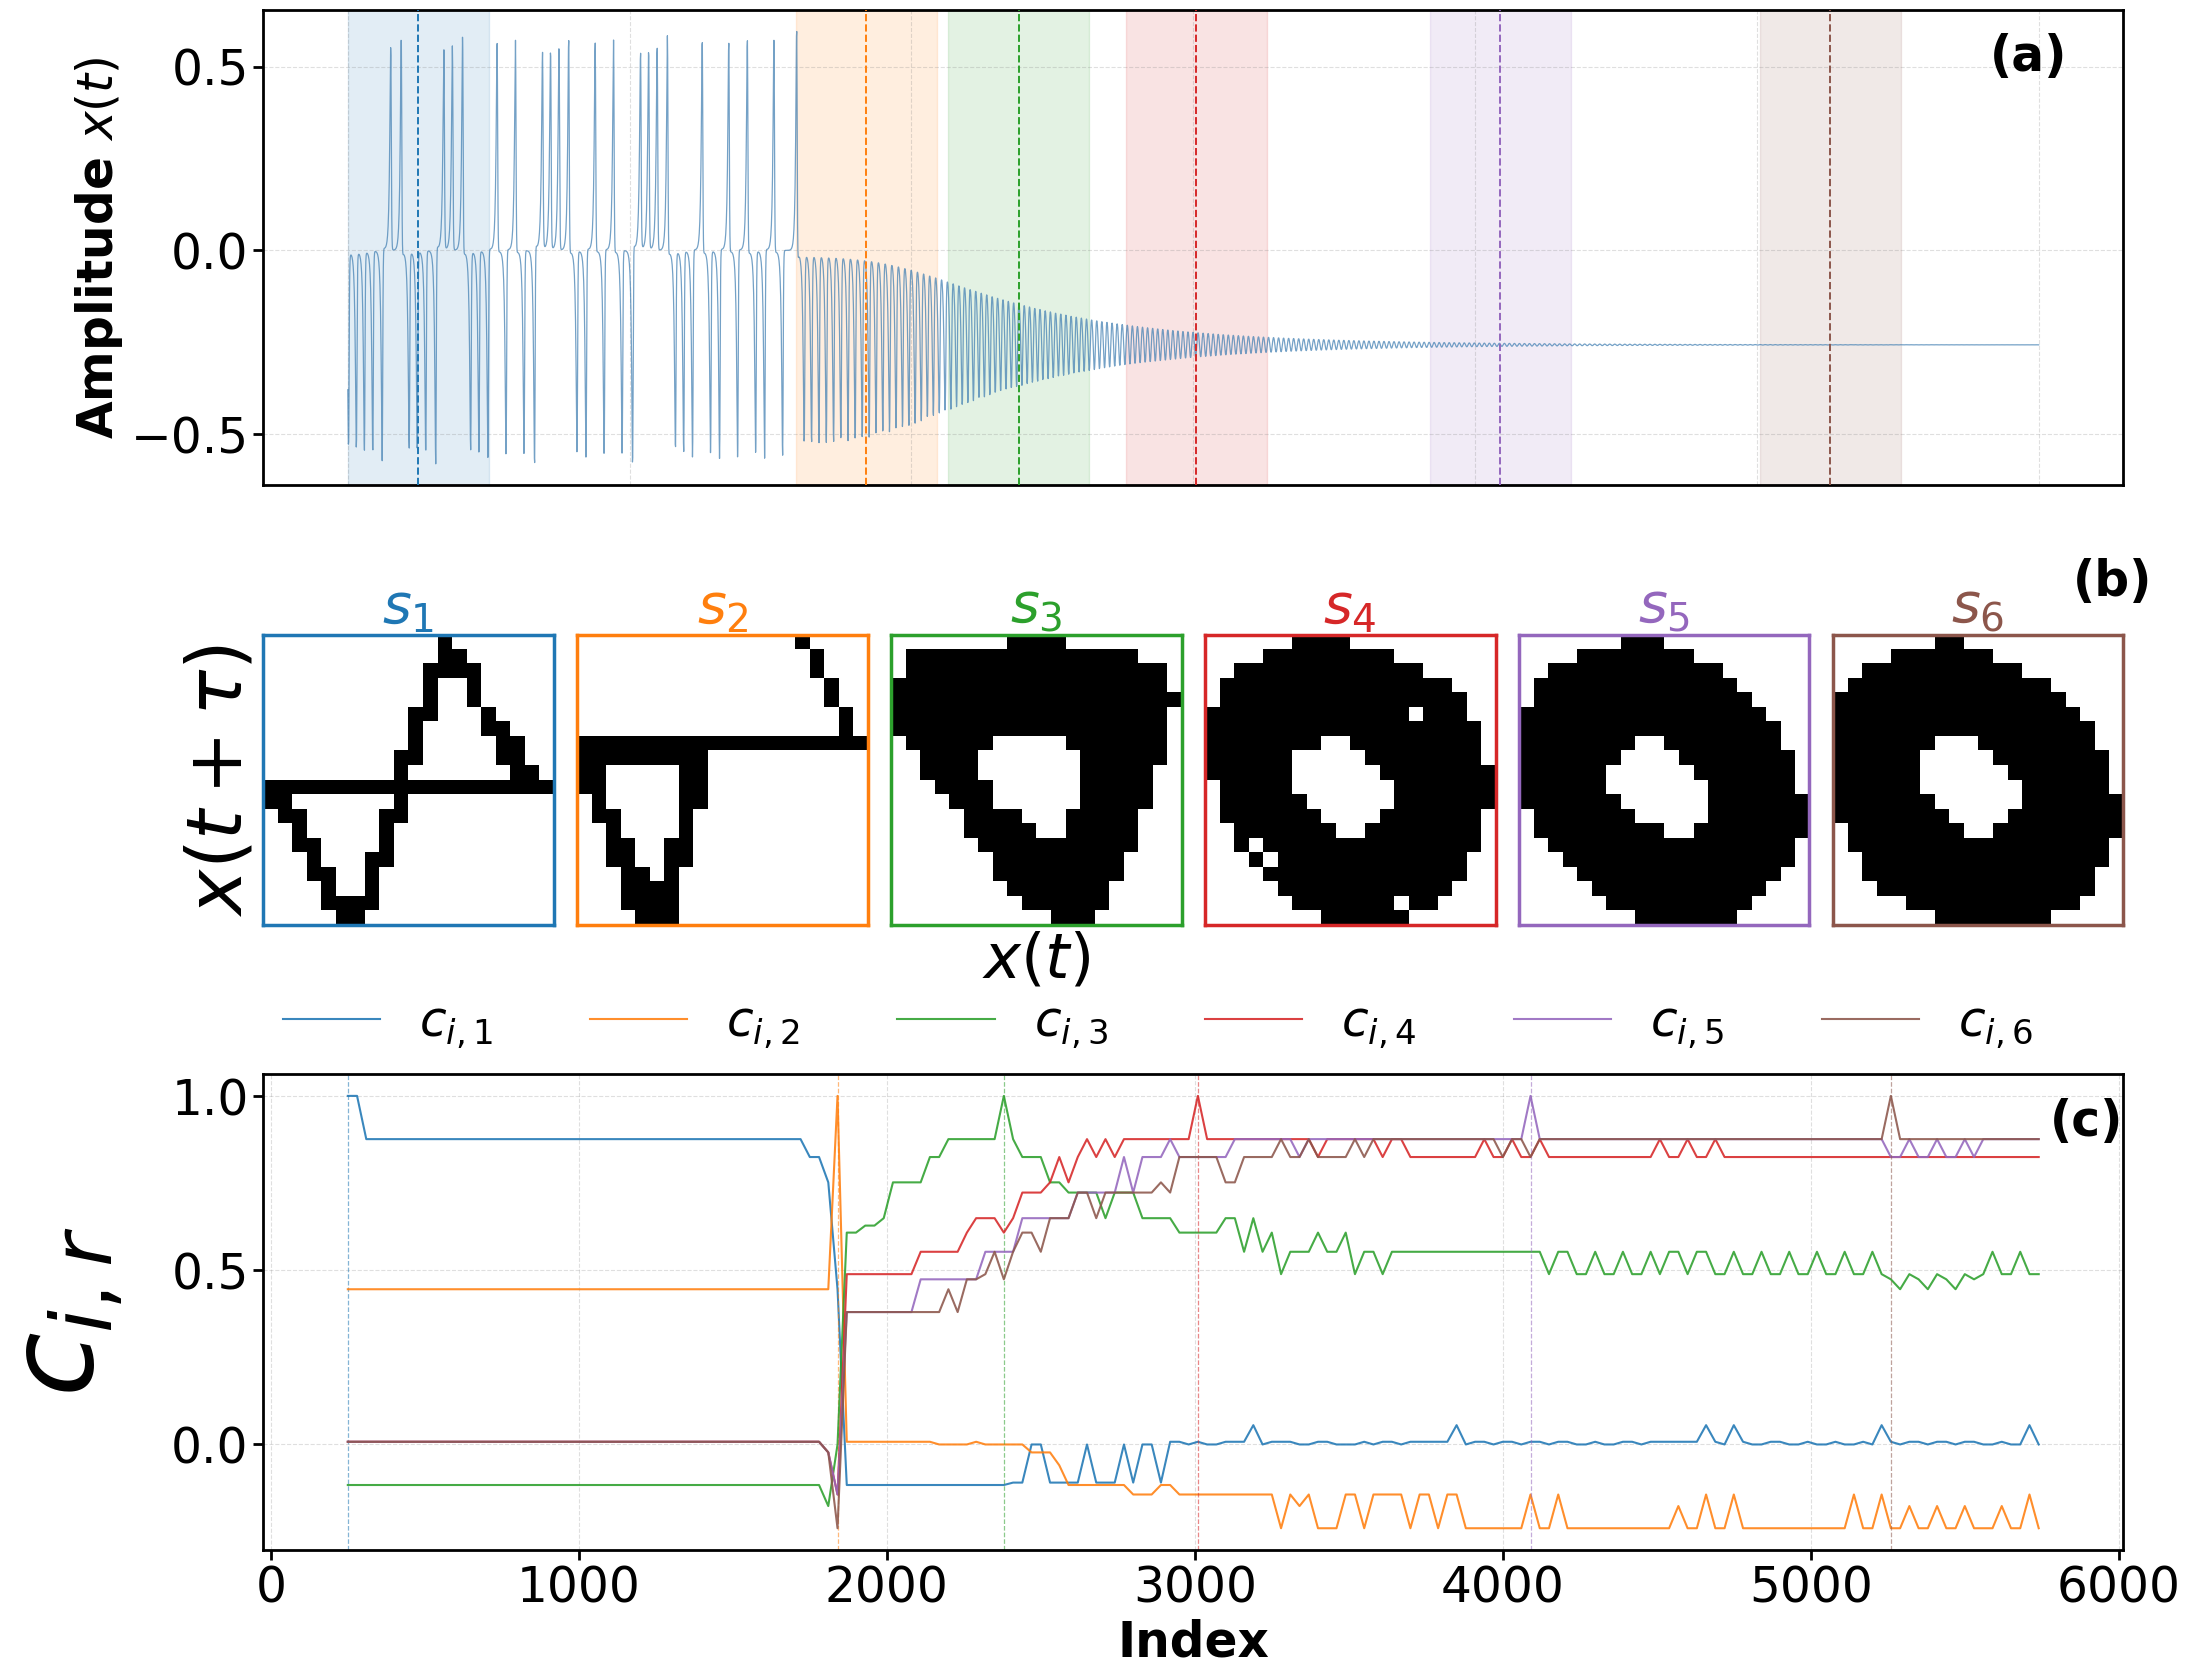

  [Fig1] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_4_HDF.pdf


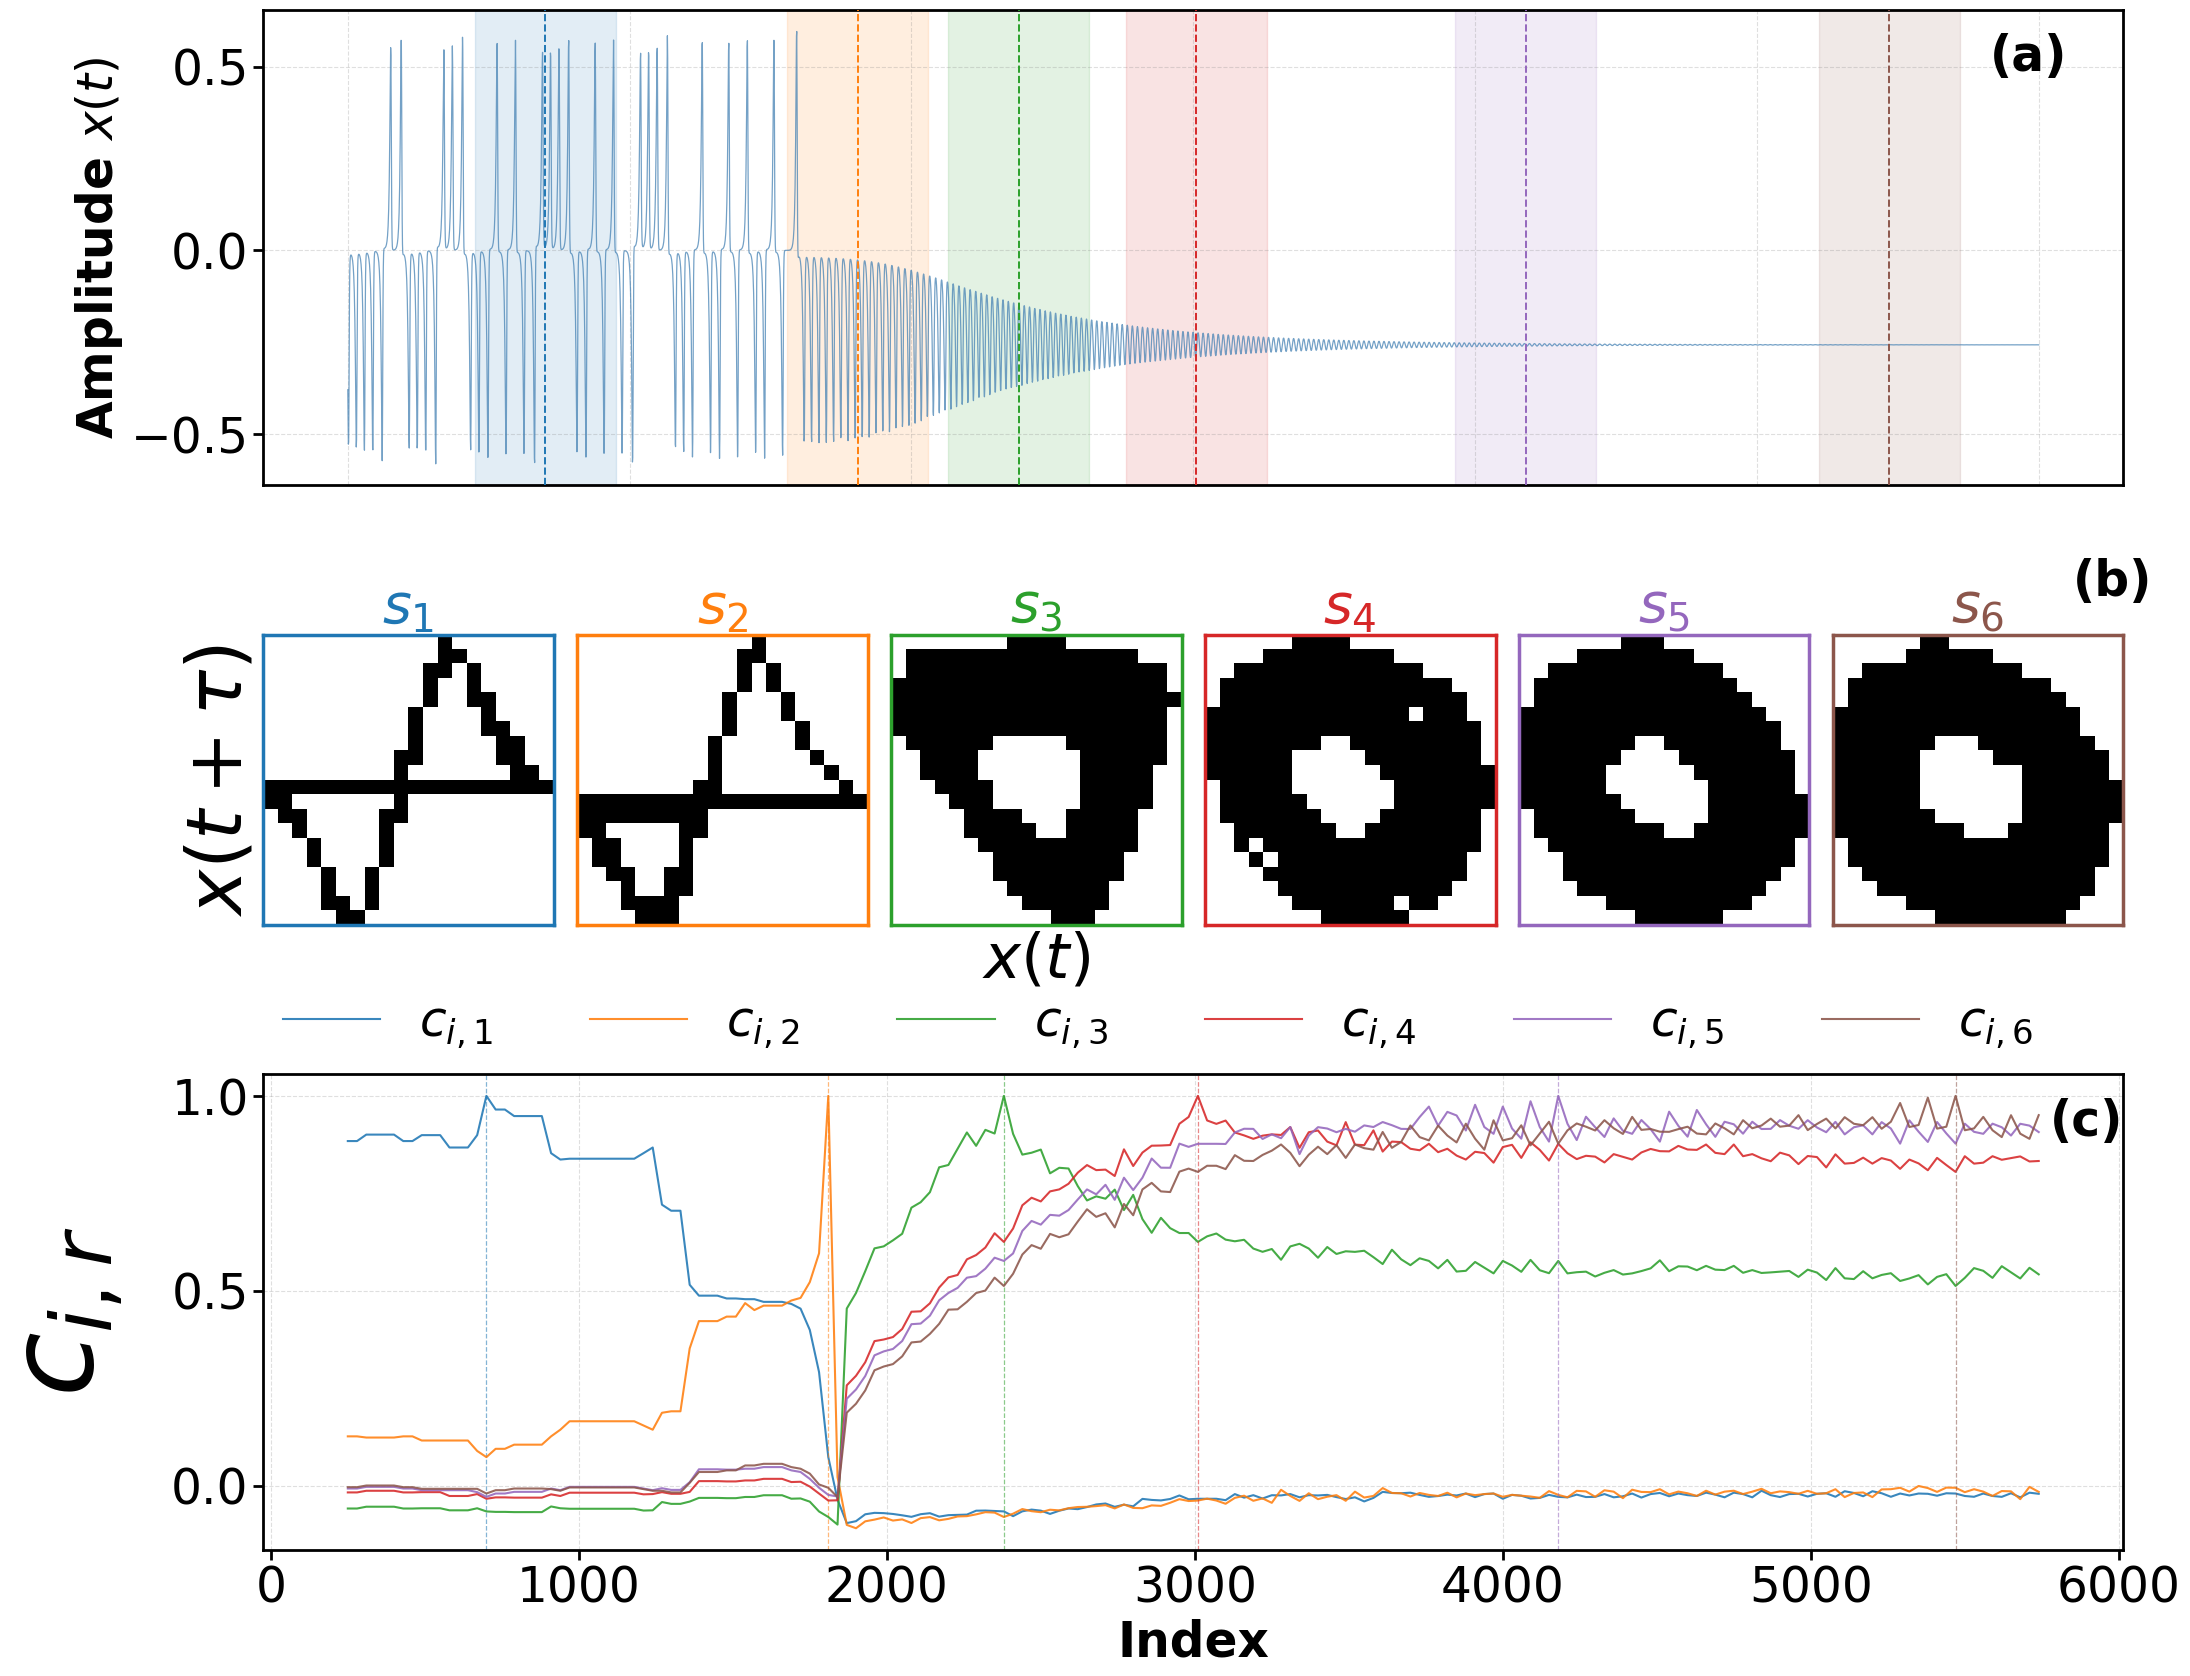

  [Fig1] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_4_IOU.pdf


In [12]:


assert 'all_compute' in globals() and all_compute, \
    "Run c04_compute first — all_compute is empty."

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.linewidth':    2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size':  7,
    'ytick.major.size':  7,
})

for dset_name, mdict in all_compute.items():
    for method, C in mdict.items():
        _P        = C['P']
        dset      = C['dset']
        signal    = C['signal']
        tsig      = C['tsig']
        centers   = C['centers']
        grids     = C['grids']
        sel       = C['sel']
        cl_mat    = C['cl_mat']
        NN_reps   = len(sel)

        rep_colors = (
            _P.COLORS_REP if len(_P.COLORS_REP) >= NN_reps
            else list(plt.cm.tab10.colors[:NN_reps])
        )

        # ── build figure with 3 rows ──────────────────────────────────────
        fig = plt.figure(
            figsize=(max(14, 4 * NN_reps), 20),
            constrained_layout=False,
        )
        outer = gridspec.GridSpec(
            3, 1, figure=fig,
            height_ratios=[3.5, 3, 3.5],   # signal | grids | closeness
            hspace=0.2,
        )

        # ── Row 0: scalar observable + coloured window bands ─────────────
        ax_sig = fig.add_subplot(outer[0])
        ax_sig.plot(tsig, signal,
                    color='steelblue', lw=0.9, alpha=0.75,
                    label='Signal $x(t)$', zorder=2)
        W = _P.T_WINDOW_STEPS
        for k, ri in enumerate(sel):
            tc = centers[ri]
            ax_sig.axvspan(tc - W // 2, tc + W // 2,
                           alpha=0.13, color=rep_colors[k], zorder=1,
                           label=f'Basis $s_{k+1}$ (idx {ri})')
            ax_sig.axvline(tc, color=rep_colors[k], lw=1.4, ls='--', zorder=3)
        #ax_sig.set_xlabel('Index', fontsize=18, fontweight='bold')
        ax_sig.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_sig.set_ylabel('Amplitude $x(t)$', fontsize=35, fontweight='bold')
        ax_sig.tick_params(labelsize=35, length=7, width=2.0)
        ax_sig.text(0.97, 0.85, '(a)', transform=ax_sig.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
        """
        ax_sig.legend(
            fontsize=13, loc='lower left',
            bbox_to_anchor=(0.0, 1.02),
            ncol=NN_reps + 1,
            borderaxespad=0, frameon=False,
        )
        """
        ax_sig.grid(True, alpha=_P.GRID_ALPHA, ls='--', color='gray')
        for sp in ax_sig.spines.values():
            sp.set_linewidth(2.0)

        # ── Row 1: binary Poincaré occupancy grids ────────────────────────
        inner_grids = gridspec.GridSpecFromSubplotSpec(
            1, NN_reps, subplot_spec=outer[1], wspace=0.08,
        )
        for k, ri in enumerate(sel):
            ax = fig.add_subplot(inner_grids[k])
            ax.imshow(grids[ri].T, origin='lower', cmap='binary',
                      interpolation='nearest', aspect='equal')
            tc          = int(centers[ri])
            # Average closeness of this representative to all other reps
            cl_others   = [cl_mat[ri, j] for j in range(NN_reps) if j != k]
            avg_cl      = float(np.mean(cl_others)) if cl_others else np.nan
            ax.set_title(
                f'$s_{k+1}$',
                fontsize=40, color=rep_colors[k], fontweight='bold',
            )
            for sp in ax.spines.values():
                sp.set_edgecolor(rep_colors[k])
                sp.set_linewidth(2.5)
            ax.set_xticks([]); ax.set_yticks([])
            if k == 0:
                ax.set_ylabel(r'$x(t+\tau)$', fontsize=55)
            if k == 2:
                ax.set_xlabel(r'$x(t)$', fontsize=45)
        ax.text(1.1,1.1, '(b)', transform=ax.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')

        # ── Row 2: normalised closeness series c_{i,r} ───────────────────
        ax_cl = fig.add_subplot(outer[2])
        for k in range(NN_reps):
            ax_cl.plot(
                centers, cl_mat[:, k],
                color=rep_colors[k], lw=1.5, alpha=0.88,
                label=f'$c_{{i,{k+1}}}$',
            )
            ax_cl.axvline(centers[sel[k]],
                          color=rep_colors[k], lw=0.9, ls='--', alpha=0.55)
        ax_cl.set_ylabel(f'$c_{{i,r}}$',
                 fontsize=85, fontweight='bold')
        ax_cl.set_xlabel('Index', fontsize=35, fontweight='bold')
        ax_cl.tick_params(labelsize=35, length=7, width=2.0)
        #ax_cl.set_ylim(-0.05, 1.05)
        ax_cl.text(1.0, 0.85, '(c)', transform=ax_cl.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
        ax_cl.legend(
                    fontsize=35,
                    ncol=6,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 1.01),          # x=0 (left edge), y just above top of axes
                    bbox_transform=ax_cl.transAxes,
                    borderaxespad=0,
                    frameon=False,                        # cleaner without the legend box frame
                )
        ax_cl.grid(True, alpha=_P.GRID_ALPHA, ls='--', color='gray')
        for sp in ax_cl.spines.values():
            sp.set_linewidth(2.0)

        fig.align_ylabels([ax_sig, ax_cl])

        fig_dir  = dset / 'Figure'
        fig_dir.mkdir(parents=True, exist_ok=True)
        out_path = fig_dir / f'Fig_4_{method}.pdf'
        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'  [Fig1] Saved: {out_path}')
        plt.close(fig)


## Figure 5 — PLSR latent dynamics and geometric FTLE proxy

This figure corresponds to the manuscript's **Fig. 5** and evaluates whether the closeness trajectories extracted in Fig. 4 contain enough supervised geometric information to reconstruct the Lyapunov-scale instability signal.

The top panel shows the first one-component PLSR latent variable, while the bottom panel compares the ML-FTLE reference $\hat{\lambda}_{\mathrm{ML}}$ with the geometry-guided reconstruction $\hat{\lambda}_{\mathrm{geo}}^{(m)}$ for the chosen dissimilarity metric.



### `c06_plot_fig2_plsr_dynamics` — Publication plot for Fig. 5

Generates the two-panel dynamic comparison used in the manuscript to evaluate the supervised geometric reconstruction.

#### Top panel — First latent variable (PC1)
The upper panel plots the z-normalised first PLSR latent variable. This supervised component compresses the multi-representative closeness matrix into a single response-relevant coordinate, isolating the dominant geometric transition that is most predictive of the ML-FTLE target.

The coloured dashed lines indicate the temporal anchors of the selected representatives, making it possible to interpret how the latent coordinate evolves relative to the basis-attractor dictionary.

#### Bottom panel — ML-FTLE versus geometric proxy
The lower panel compares the black ML-FTLE trajectory $\hat{\lambda}_{\mathrm{ML}}$ with the metric-specific geometric reconstruction $\hat{\lambda}_{\mathrm{geo}}^{(m)}$. This is the core validation step of the manuscript's Poincaré-FTLE framework: it tests whether coarse occupancy-grid geometry, once projected through supervised latent-variable regression, can reproduce the instability transition on the Lyapunov scale.

For the SSIM manuscript example, this panel demonstrates that the geometric proxy tracks the abrupt collapse with reduced lag and flattens appropriately in the stable regime, thereby confirming that the structural evolution of the attractor contains sufficient deterministic information to recover the macroscopic FTLE transition.



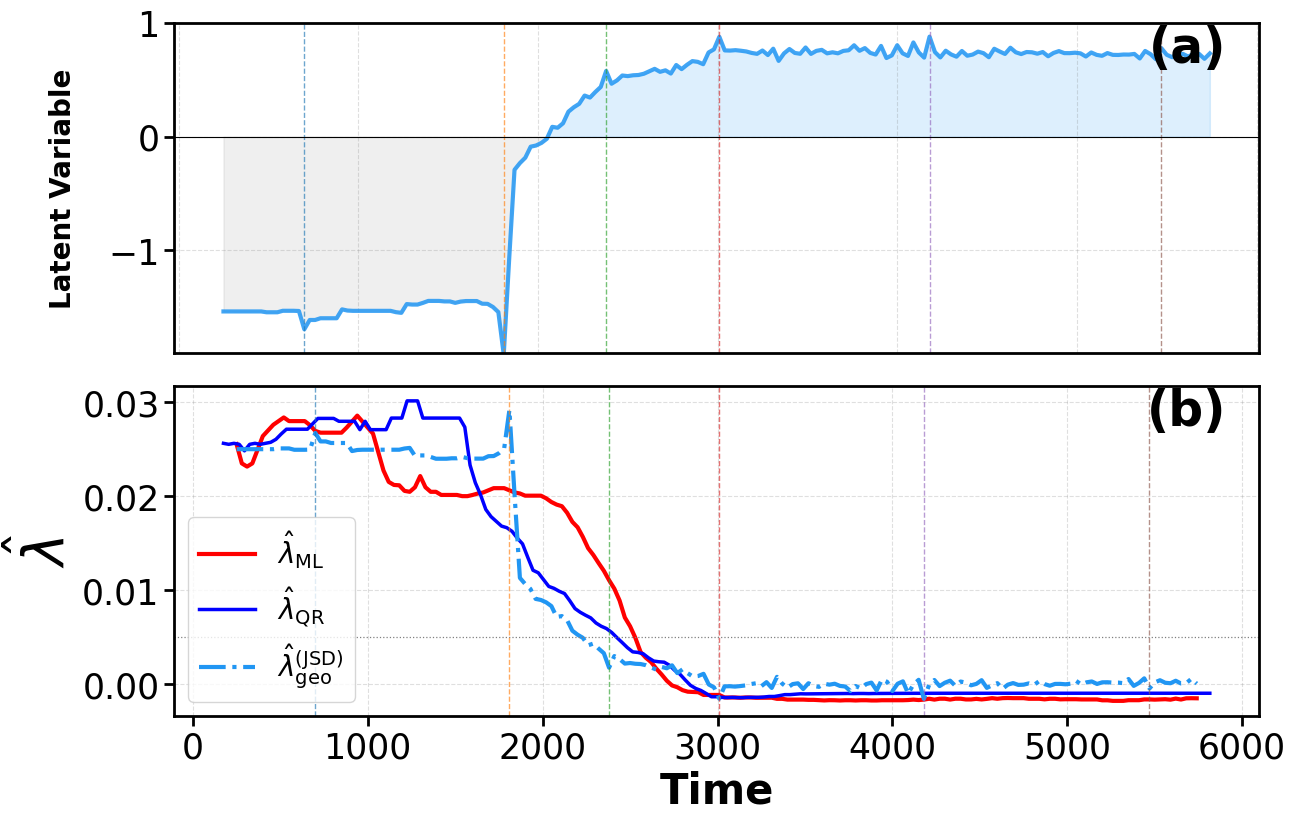

  [Fig2] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_5_JSD.pdf


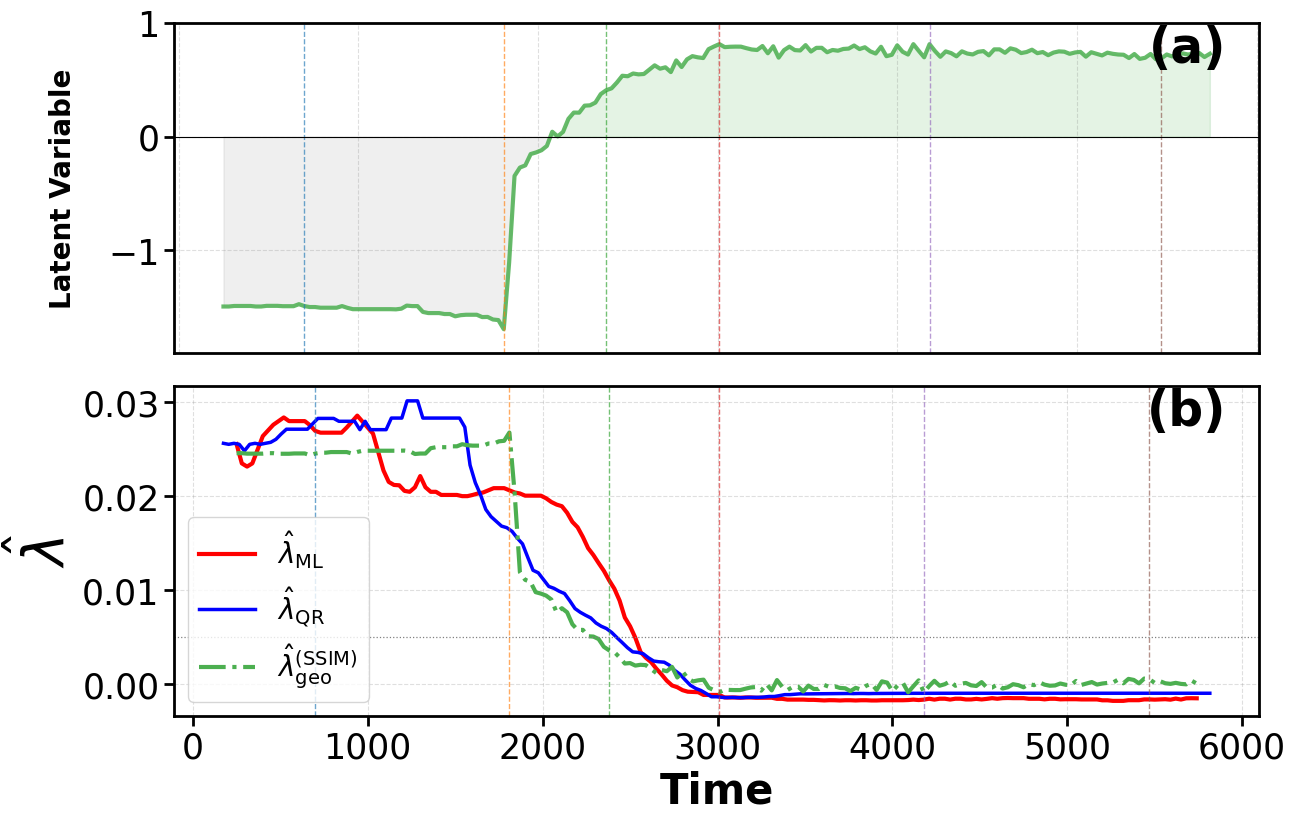

  [Fig2] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_5_SSIM.pdf


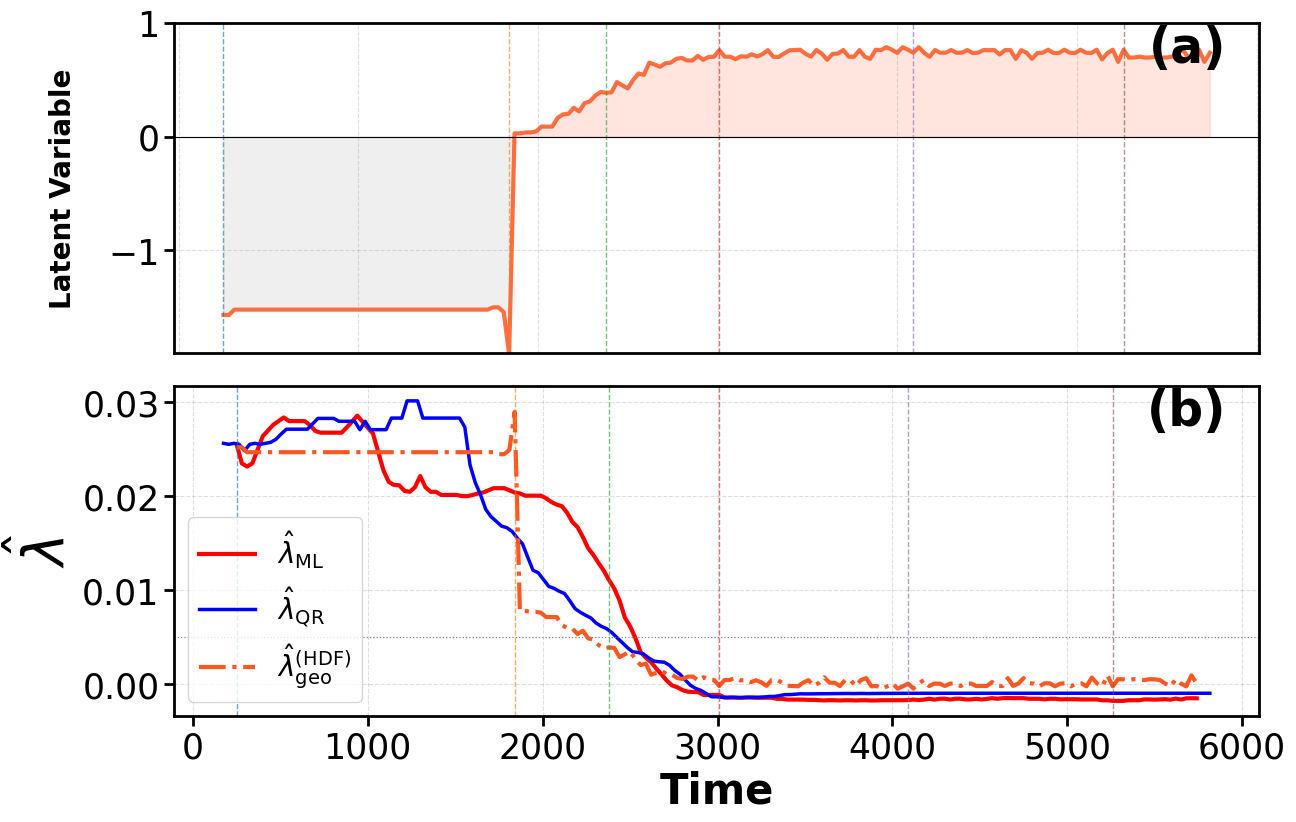

  [Fig2] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_5_HDF.pdf


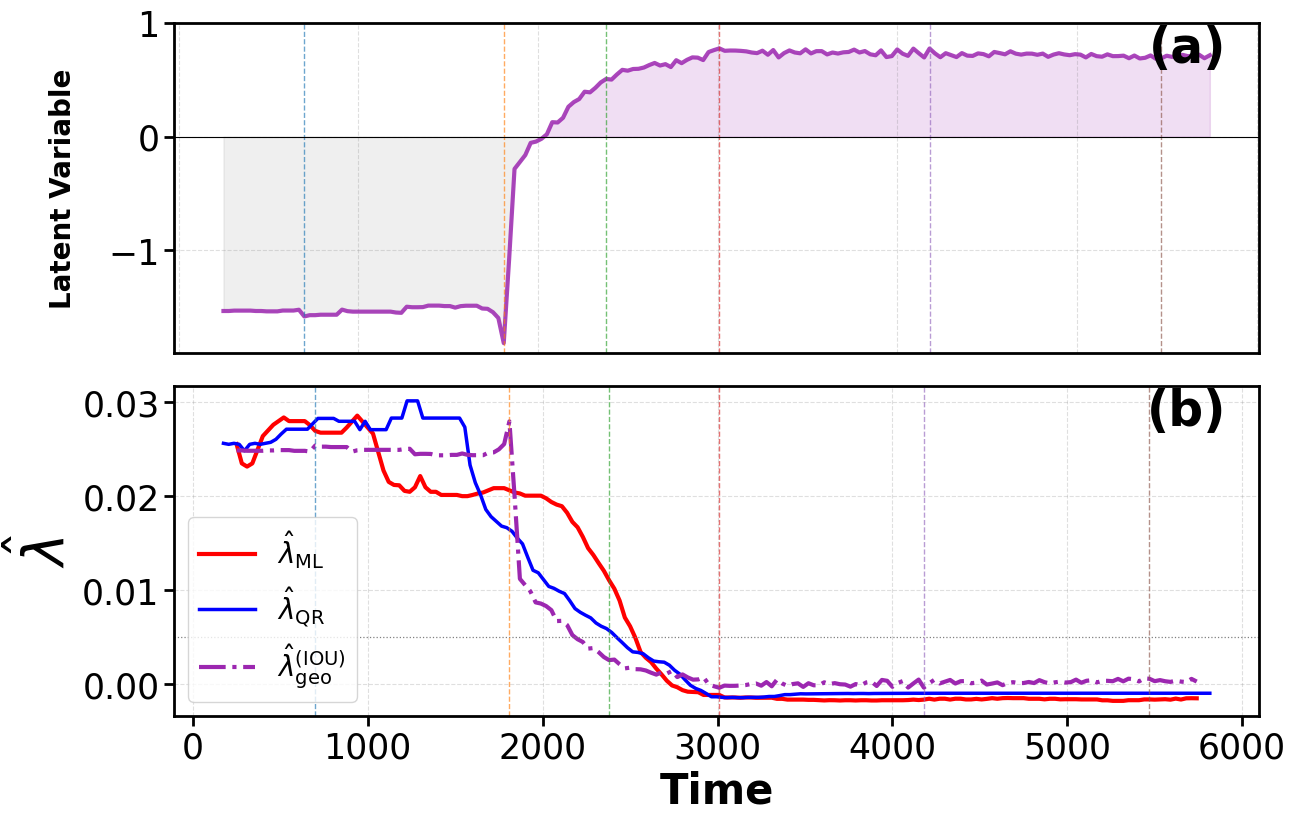

  [Fig2] Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_5_IOU.pdf


In [13]:
assert 'all_compute' in globals() and all_compute, \
    "Run c04_compute first — all_compute is empty."

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.linewidth':    2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size':  7,
    'ytick.major.size':  7,
})

for dset_name, mdict in all_compute.items():
    for method, C in mdict.items():
        _P       = C['P']
        dset     = C['dset']
        centers  = C['centers']
        sel      = C['sel']
        t_ftle   = C['t_ftle']
        lam_ml   = C['lam_ml']
        pred     = C['pred']
        plsr_rho = C['plsr_rho']
        pc1      = C['pc1']
        t_pc1    = C['t_pc1']
        NN_reps  = len(sel)

        col        = _P.METHOD_COLORS.get(method, '#888')
        rep_colors = (
            _P.COLORS_REP if len(_P.COLORS_REP) >= NN_reps
            else list(plt.cm.tab10.colors[:NN_reps])
        )

        fig = plt.figure(figsize=(14, 9), constrained_layout=False)
        outer = gridspec.GridSpec(
            2, 1, figure=fig,
            height_ratios=[1, 1],
            hspace=0.1,
        )

        # ── Row 0: PLSR latent variable PC1 (z-normalised) ───────────────
        ax_pc1 = fig.add_subplot(outer[0])
        if pc1 is not None and t_pc1 is not None:
            pc1_n = (pc1 - np.nanmean(pc1)) / (np.nanstd(pc1) + EPS)
            ax_pc1.plot(t_pc1, pc1_n, color=col, lw=3, alpha=0.85,
                        label='Latent Variance PC1 (z-norm)')
            ax_pc1.fill_between(t_pc1, 0, pc1_n,
                                where=(pc1_n >= 0), color=col,
                                alpha=0.15, interpolate=True)
            ax_pc1.fill_between(t_pc1, 0, pc1_n,
                                where=(pc1_n < 0), color='gray',
                                alpha=0.12, interpolate=True)
            for k, ri in enumerate(sel):
                ax_pc1.axvline(centers[ri], color=rep_colors[k],
                               lw=1.0, ls='--', alpha=0.65,
                               label=f'Basis $s_{k+1}$')
            ax_pc1.axhline(0, color='black', lw=0.8)
        else:
            ax_pc1.text(0.5, 0.5, 'PC1 not available',
                        ha='center', va='center',
                        transform=ax_pc1.transAxes,
                        fontsize=14, color='gray')
        ax_pc1.set_ylabel('Latent Variable', fontsize=20, fontweight='bold')
        ax_pc1.set_ylim(-1.9, 1)
        #ax_pc1.set_xlabel('Index', fontsize=18, fontweight='bold')
        ax_pc1.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_pc1.tick_params(labelsize=25, length=7, width=2.0)
        ax_pc1.text(0.97, 0.85, '(a)', transform=ax_pc1.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
        ax_pc1.grid(True, alpha=_P.GRID_ALPHA, ls='--', color='gray')
        for sp in ax_pc1.spines.values():
            sp.set_linewidth(2.0)
    
        # ── Row 1: ML-FTLE (black) + geometry-guided PLSR proxy (colour) ─
        ax_ftle = fig.add_subplot(outer[1])
        if t_ftle is not None and lam_ml is not None:
            ax_ftle.plot(t_ftle, lam_ml,
                         color='red', lw=3, alpha=1,
                         label=r'$\hat{\lambda}_{\mathrm{ML}}$')
            
            # ── QR-FTLE reference (load once per dataset-method iteration) ──────────────
            qr_csv = dset / 'qr_ftle.csv'
            if qr_csv.exists():
                df_qr   = pd.read_csv(qr_csv)
                t_qr    = df_qr.iloc[:, 0].values.astype(float)
                lam_qr  = df_qr.iloc[:, 4].values.astype(float)
                ax_ftle.plot(t_qr, lam_qr,
                            color='blue', lw=2.5, #ls=':', alpha=0.85,
                            label=r'$\hat{\lambda}_{\mathrm{QR}}$')
            if pred is not None:
                rho_lbl = f', $\\rho={plsr_rho:.3f}$' if plsr_rho is not None else ''
                ax_ftle.plot(
                    t_ftle, pred,
                    color=col, lw=3, ls='-.', alpha=1,
                    label=rf'$\hat{{\lambda}}_{{\mathrm{{geo}}}}^{{(\mathrm{{{method}}})}}$'
                )
            ax_ftle.axhline(_P.LLE_THRESH, lw=0.9, ls=':', color='gray',)
            for k, ri in enumerate(sel):
                ax_ftle.axvline(centers[ri], color=rep_colors[k],
                                lw=1.0, ls='--', alpha=0.65)
        ax_ftle.set_ylabel(r'$\hat{\lambda}$', fontsize=40, fontweight='bold')
        ax_ftle.set_xlabel('Time', fontsize=30, fontweight='bold')
        ax_ftle.tick_params(labelsize=25, length=7, width=2.0)
        ax_ftle.legend(fontsize=20, loc='lower left', ncol=1)
        ax_ftle.text(0.97, 0.85, '(b)', transform=ax_ftle.transAxes, fontsize=35, fontweight='bold', va='bottom', ha='right')
        ax_ftle.grid(True, alpha=_P.GRID_ALPHA, ls='--', color='gray')
        for sp in ax_ftle.spines.values():
            sp.set_linewidth(2.0)

        fig.align_ylabels([ax_pc1, ax_ftle])

        fig_dir  = dset / 'Figure'
        fig_dir.mkdir(parents=True, exist_ok=True)
        out_path = fig_dir / f'Fig_5_{method}.pdf'
        plt.savefig(out_path, dpi=1200, bbox_inches='tight')
        plt.show()
        print(f'  [Fig2] Saved: {out_path}')
        plt.close(fig)

### `c07_summary` — Summary table of representatives and PLSR agreement

Prints a compact table containing, for every dataset-method pair, the selected representative indices, the PLSR correlation coefficient, and the availability of the latent variable.

This cell is useful for manuscript cross-checking because it provides a quick audit of which representative windows were chosen by each dissimilarity metric and how strongly the corresponding geometric reconstruction aligns with the ML-FTLE reference.



In [14]:
print(f'{"Dataset":20s}  {"Method":8s}  {"Representatives":40s}  {"PLSR ρ":8s}  PC1?')
print('-' * 90)
for ds, mdict in all_compute.items():
    for method, C in mdict.items():
        rho_str = f"{C['plsr_rho']:.3f}" if C['plsr_rho'] is not None else 'N/A'
        pc1_str = '✓' if C['pc1'] is not None else '✗'
        print(f"{ds:20s}  {method:8s}  {str(C['sel']):40s}  {rho_str:8s}  {pc1_str}")


Dataset               Method    Representatives                           PLSR ρ    PC1?
------------------------------------------------------------------------------------------
data_1                JSD       [15, 52, 71, 92, 131, 174]                0.835     ✓
data_1                SSIM      [15, 52, 71, 92, 131, 174]                0.789     ✓
data_1                HDF       [0, 53, 71, 92, 128, 167]                 0.861     ✓
data_1                IOU       [15, 52, 71, 92, 131, 174]                0.821     ✓
